# 03. 회전과 지형류 조정 (geostrophic adjustment)

이제 **코리올리 항**을 더한다. f-평면에서 선형 천수방정식은

$$
\frac{\partial u}{\partial t} - f v = -g\frac{\partial \eta}{\partial x},\quad
\frac{\partial v}{\partial t} + f u = -g\frac{\partial \eta}{\partial y},\quad
\frac{\partial \eta}{\partial t} + H\Big(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\Big)=0
$$

회전이 빠르면(시간이 충분하면) 흐름은 **지형류 평형(geostrophic balance)** 으로
조정된다.

$$
f v = g\frac{\partial \eta}{\partial x}, \qquad f u = -g\frac{\partial \eta}{\partial y}
$$

조정의 공간 규모는 **Rossby 변형반지름**

$$
L_d = \frac{\sqrt{gH}}{f}
$$

이다. 학습 목표:

1. 초기 단차(rest)가 어떻게 조정되는가 — **관성-중력파** 방출 + 지형류 jet 형성
2. **변형반지름 $L_d$** 가 조정 규모를 정한다는 것
3. 운동/위치 에너지의 재분배
4. **위치소용돌이도(PV)** $q=\zeta-\tfrac{f}{H}\eta$ 의 보존
5. 최종 상태가 지형류 평형을 만족함을 확인

## 1. 라이브러리와 파라미터

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from shallow_water.grids.cgrid import CGrid
from shallow_water.dynamics.swe2d import ShallowWater2D
from shallow_water.dynamics import diagnostics as diag
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT); FIG = OUT["figures"]

g, H, f0 = 9.81, 500.0, 1e-4          # c≈70 m/s, Ld≈700 km
Lx, Ly, nx, ny = 1.2e7, 2e6, 240, 40  # 12000 km × 2000 km, dx=dy=50 km
grid = CGrid(nx=nx, ny=ny, Lx=Lx, Ly=Ly)
model = ShallowWater2D(grid=grid, g=g, H=H, f0=f0)
c = model.gravity_wave_speed(); Ld = model.deformation_radius()
Tin = 2 * np.pi / f0
dt = 0.4 * grid.dx / (c * np.sqrt(2))
print(f"c = {c:.1f} m/s,  Ld = {Ld/1e3:.0f} km,  관성주기 = {Tin/3600:.1f} h")
print(f"dx = {grid.dx/1e3:.0f} km ({grid.dx/Ld:.2f} Ld),  dt = {dt:.0f} s,  CFL = {model.cfl(dt):.2f}")

c = 70.0 m/s,  Ld = 700 km,  관성주기 = 17.5 h
dx = 50 km (0.07 Ld),  dt = 202 s,  CFL = 0.40


## 2. 단차의 지형류 조정

정지 상태($u=v=0$)에서 $x$ 방향 단차 $\eta_0(x)=\eta_a\tanh\!\big((x-x_c)/W\big)$
($y$ 에 무관)를 놓는다. 이는 Gill 의 고전적 조정 문제다. 흐름은
관성-중력파를 방출하며 단차 근처에 폭 $\sim L_d$ 의 **남북 jet($v$)** 을 만든다.

In [2]:
X, Y = grid.meshgrid_eta()
xc = Lx / 2
W = Ld                                   # 초기 단차 폭 ~ Ld
eta_a = 0.5
eta0 = eta_a * np.tanh((X - xc) / W)
u0 = np.zeros((ny, nx + 1)); v0 = np.zeros((ny + 1, nx))

T = 2.2 * Tin
nsteps = int(round(T / dt))
res = model.run(eta0, u0, v0, dt, nsteps=nsteps, save_every=max(1, nsteps // 80))
times = res["save_times"]
print(f"{nsteps} steps, {len(res['eta_hist'])} snapshots, T = {T/Tin:.1f} 관성주기")

685 steps, 86 snapshots, T = 2.2 관성주기


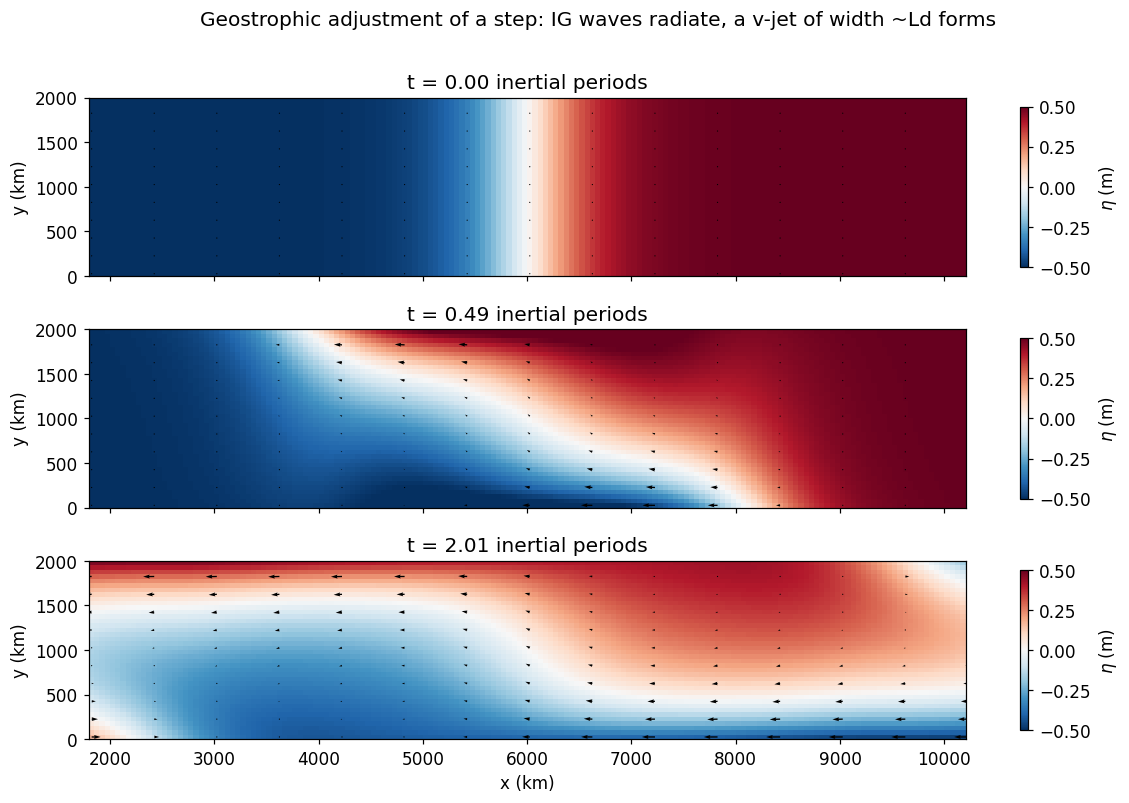

In [3]:
def centers(uu, vv):
    return grid.u_at_center(uu), grid.v_at_center(vv)

targets = [0.0, 0.5 * Tin, 2.0 * Tin]
fig, axes = plt.subplots(3, 1, figsize=(11, 7.2), sharex=True)
xkm, ykm = grid.x_eta / 1e3, grid.y_eta / 1e3
skip = 12
for ax, tt in zip(axes, targets):
    k = int(np.argmin(np.abs(times - tt)))
    im = ax.pcolormesh(xkm, ykm, res["eta_hist"][k], cmap="RdBu_r",
                       vmin=-eta_a, vmax=eta_a, shading="auto")
    uc, vc = centers(res["u_hist"][k], res["v_hist"][k])
    ax.quiver(xkm[::skip], ykm[::4], uc[::4, ::skip], vc[::4, ::skip],
              color="k", scale=8, width=0.0015)
    ax.set_ylabel("y (km)"); ax.set_title(f"t = {times[k]/Tin:.2f} inertial periods")
    fig.colorbar(im, ax=ax, label=r"$\eta$ (m)", shrink=0.9)
axes[-1].set_xlabel("x (km)")
# 중심 부근만 확대해서 jet 이 보이도록
for ax in axes:
    ax.set_xlim(xc/1e3 - 6*Ld/1e3, xc/1e3 + 6*Ld/1e3)
fig.suptitle("Geostrophic adjustment of a step: IG waves radiate, a v-jet of width ~Ld forms", y=1.01)
fig.tight_layout(); fig.savefig(FIG / "03_adjustment.png", bbox_inches="tight"); plt.show()

## 3. 에너지 재분배

처음엔 위치에너지(PE)만 있다($u=v=0$). 조정되면서 일부는 운동에너지(KE)로
바뀌어 jet 을 만들고, 일부는 관성-중력파로 방출된다(닫힌 분지라 파동은
도메인 안을 돌아다닌다).

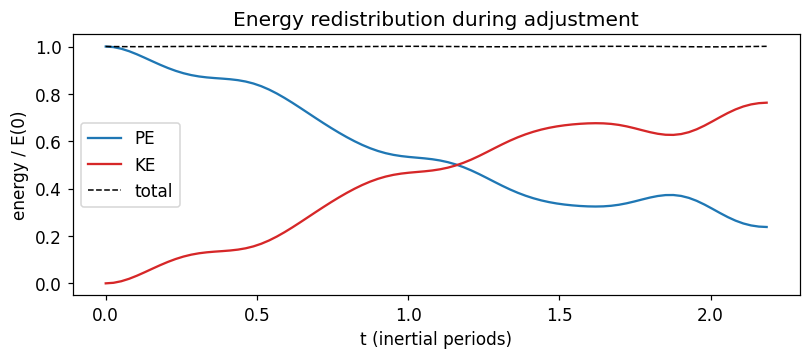

In [4]:
KE, PE = [], []
for e, uu, vv in zip(res["eta_hist"], res["u_hist"], res["v_hist"]):
    comp = diag.energy_components(grid, e, uu, vv, g, H)
    KE.append(comp["KE"]); PE.append(comp["PE"])
KE, PE = np.array(KE), np.array(PE)
E0 = KE[0] + PE[0]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(times / Tin, PE / E0, "C0", label="PE")
ax.plot(times / Tin, KE / E0, "C3", label="KE")
ax.plot(times / Tin, (KE + PE) / E0, "k--", lw=1, label="total")
ax.set_xlabel("t (inertial periods)"); ax.set_ylabel("energy / E(0)")
ax.set_title("Energy redistribution during adjustment"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "03_energy_partition.png", bbox_inches="tight"); plt.show()

## 4. 최종 상태의 지형류 평형

단차가 $y$ 에 무관하므로 최종 jet 은 $v$ 성분이다. 시간평균(관성진동 제거)한
최종 상태가 $f\,v \approx g\,\partial\eta/\partial x$ 를 만족하는지 확인한다.

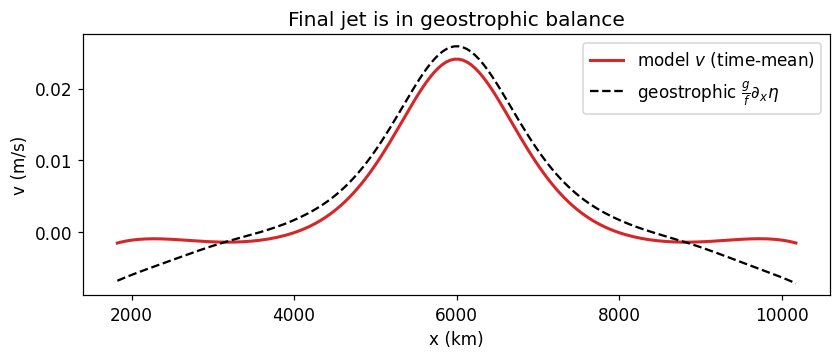

In [5]:
# 마지막 ~1 관성주기를 시간평균해 관성진동을 걸러낸다
mask = times > (times[-1] - Tin)
idx = np.where(mask)[0]
eta_bar = np.mean([res["eta_hist"][k] for k in idx], axis=0)
u_bar = np.mean([res["u_hist"][k] for k in idx], axis=0)
v_bar = np.mean([res["v_hist"][k] for k in idx], axis=0)
vc_bar = grid.v_at_center(v_bar)

jmid = ny // 2
detadx = np.gradient(eta_bar[jmid], grid.dx)
fig, ax = plt.subplots(figsize=(8, 3.4))
sel = (xkm > xc/1e3 - 6*Ld/1e3) & (xkm < xc/1e3 + 6*Ld/1e3)
ax.plot(xkm[sel], vc_bar[jmid][sel], "C3", lw=2, label=r"model $v$ (time-mean)")
ax.plot(xkm[sel], (g / f0) * detadx[sel], "k--", label=r"geostrophic $\frac{g}{f}\partial_x\eta$")
ax.set_xlabel("x (km)"); ax.set_ylabel("v (m/s)")
ax.set_title("Final jet is in geostrophic balance"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "03_geostrophic_balance.png", bbox_inches="tight"); plt.show()

## 5. 위치소용돌이도(PV) 보존

선형 천수방정식에서 $q=\zeta-\dfrac{f}{H}\eta$ 는 $\partial q/\partial t=0$ 이라 보존된다.
초기와 최종(시간평균)의 $q(x)$ 가 거의 겹쳐야 한다. PV 가 보존되기 때문에
단차는 완전히 평평해지지 못하고 **부분적으로만 슬럼프(slump)** 한다.

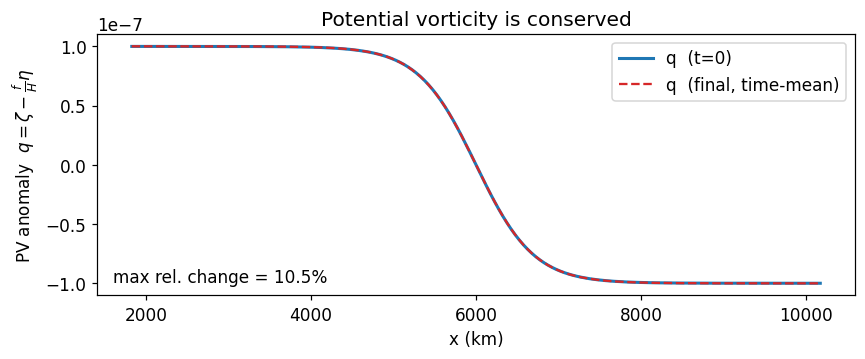

PV 최대 상대변화: 10.48%


In [6]:
# 시간평균 최종 상태(관성-중력파 제거)로 PV 를 비교한다
q0 = diag.potential_vorticity(grid, eta0, u0, v0, f0, H)
q_end = diag.potential_vorticity(grid, eta_bar, u_bar, v_bar, f0, H)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(xkm[sel], q0[jmid][sel], "C0", lw=2, label="q  (t=0)")
ax.plot(xkm[sel], q_end[jmid][sel], "C3--", label="q  (final, time-mean)")
ax.set_xlabel("x (km)"); ax.set_ylabel(r"PV anomaly  $q=\zeta-\frac{f}{H}\eta$")
ax.set_title("Potential vorticity is conserved")
ax.legend()
err = np.max(np.abs(q_end - q0)[:, 5:-5]) / np.max(np.abs(q0))
ax.text(0.02, 0.05, f"max rel. change = {err*100:.1f}%", transform=ax.transAxes)
fig.tight_layout(); fig.savefig(FIG / "03_pv_conservation.png", bbox_inches="tight"); plt.show()
print(f"PV 최대 상대변화: {err*100:.2f}%")

## 6. 변형반지름이 조정 규모를 정한다

초기 단차 폭 $W$ 가 $L_d$ 보다 작아도, 조정 후 jet 의 폭은 $\sim L_d$ 로 넓어진다.
$L_d$ 는 회전이 흐름에 부여하는 **고유 수평규모**다. 서로 다른 $W$ 로 시작해
최종 jet(시간평균 $v$)을 비교한다.

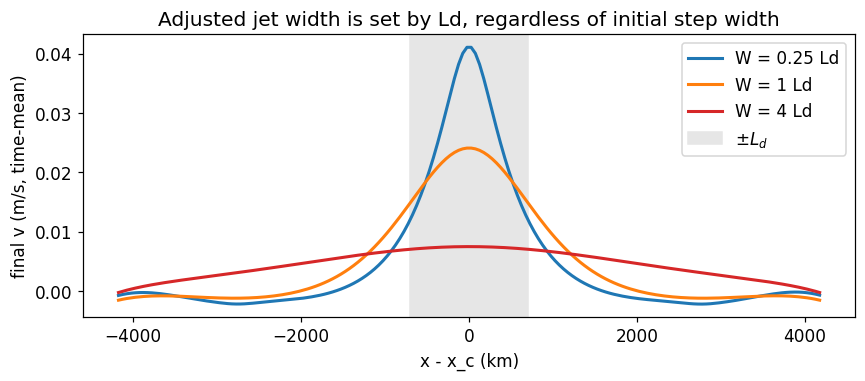

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for W_frac, col in zip([0.25, 1.0, 4.0], ["C0", "C1", "C3"]):
    e0 = eta_a * np.tanh((X - xc) / (W_frac * Ld))
    r = model.run(e0, u0.copy(), v0.copy(), dt, nsteps=nsteps,
                  save_every=max(1, nsteps // 40), track_energy=False)
    tt = r["save_times"]; mk = tt > (tt[-1] - Tin)
    vbar = grid.v_at_center(np.mean([r["v_hist"][k] for k in np.where(mk)[0]], axis=0))
    ax.plot((xkm - xc/1e3)[sel], vbar[jmid][sel], col, lw=2,
            label=f"W = {W_frac:g} Ld")
ax.axvspan(-Ld/1e3, Ld/1e3, color="0.9", zorder=0, label=r"$\pm L_d$")
ax.set_xlabel("x - x_c (km)"); ax.set_ylabel("final v (m/s, time-mean)")
ax.set_title("Adjusted jet width is set by Ld, regardless of initial step width")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "03_ld_dependence.png", bbox_inches="tight"); plt.show()

## 7. 정리

- 코리올리 항을 더해 **지형류 조정**을 재현했다: 단차가 관성-중력파를 방출하며
  폭 $\sim L_d$ 의 지형류 jet 으로 조정된다.
- 최종 jet 은 $f v = g\,\partial_x\eta$ 의 **지형류 평형**을 만족한다.
- **위치소용돌이도** $q=\zeta-\frac{f}{H}\eta$ 가 보존되어, 단차는 완전히
  평평해지지 못하고 부분적으로만 조정된다.
- **변형반지름 $L_d=\sqrt{gH}/f$** 가 조정의 공간 규모를 정한다.

다음(Stage 4)에서는 경계와 $\beta$-효과가 만드는 **회전계 파동(Kelvin·Rossby)** 을
다룬다.